# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv
import pickle
import joblib

import inflect
import unicodedata
import re

import ast

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

from processing import *
from geography import check_border, bordering_countries, get_guess_temperature, temp_to_thresholds, get_country_distance, get_guess_direction

In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

# Data Cleaning

### Overview / optional ingredient processing

In [3]:
df = pd.read_csv('data/data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [4]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [5]:
cleaned_df['countries_of_origin'].explode().value_counts().head(20) / len(cleaned_df) * 100.0

countries_of_origin
United States     6.32
Japan             4.54
China             4.54
Italy             4.32
United Kingdom    4.32
Indonesia         4.26
Philippines       4.04
India             3.92
Germany           3.68
France            3.68
Spain             3.64
South Korea       3.24
Turkey            2.78
Canada            2.74
North Korea       2.40
Thailand          2.34
Mexico            2.32
Peru              2.30
Malaysia          2.22
Australia         2.06
Name: count, dtype: float64

In [6]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

2242

Text(0.5, 0, 'Number of dishes for country of origin')

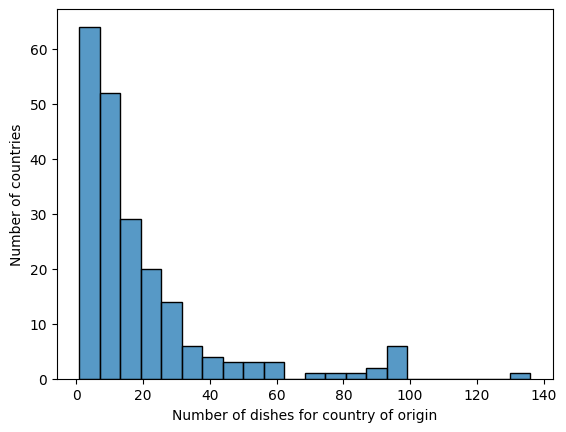

In [7]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())
plt.ylabel("Number of countries")
plt.xlabel("Number of dishes for country of origin")

In [8]:
# countries included if cutting off least frequent 150 countries
unique_dishes_df['countries_of_origin'].explode().value_counts().head(197 - 150)

countries_of_origin
United States     136
United Kingdom     98
Japan              98
Indonesia          98
Philippines        96
China              96
India              94
Italy              90
France             90
Spain              81
South Korea        76
Germany            73
Mexico             60
Thailand           59
Turkey             59
North Korea        56
Canada             56
Malaysia           52
Brazil             49
Peru               46
Iran               45
Vietnam            41
Singapore          41
Georgia            38
Australia          38
Sweden             37
Azerbaijan         35
Armenia            33
Russia             33
Poland             32
Algeria            32
Pakistan           31
Hong Kong          31
Egypt              30
Bangladesh         30
Portugal           30
Finland            29
Taiwan             29
Nepal              29
Nigeria            28
Colombia           28
Greece             28
Myanmar            27
Netherlands        27
Romania     

In [9]:
unique_dishes_df['countries_of_origin'].explode().value_counts().iloc[50:100]

countries_of_origin
Argentina                 25
New Zealand               24
Denmark                   24
Croatia                   23
Serbia                    23
Chile                     23
Cuba                      22
Palestine                 21
Ghana                     21
Lebanon                   21
Lithuania                 21
Syria                     20
Mauritania                20
Belarus                   20
Bulgaria                  20
Macau                     19
Morocco                   19
Jordan                    19
Libya                     19
Bolivia                   18
Ecuador                   18
Switzerland               18
Belgium                   18
Slovenia                  18
Brunei                    17
Trinidad and Tobago       17
Laos                      17
Ireland                   17
Israel                    17
Iraq                      17
Cyprus                    17
Norway                    17
South Africa              17
Moldova                

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [10]:
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [11]:
from fuzzywuzzy import fuzz
from itertools import combinations

ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()
pairs = list(combinations(ingredients, 2))

# Calculate similarities
#similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]
#similarities.sort(key=lambda x: x[1], reverse=True)

In [12]:
#similarities[:40]

In [13]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      1250
garlic     930
onion      809
sugar      694
water      549
egg        484
butter     484
pepper     447
flour      382
tomato     366
Name: count, dtype: int64

### Make connections between base and processed ingredient names ("Raw fish" and "fish" are related)

In [14]:
ingredients = unique_dishes_df['ingredients'].explode()

one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]

len(one_word_ingredients.value_counts())

682

In [15]:
most_common_300 = most_common_one_word_ings_train(unique_dishes_df, how_many=300)
add_base_ingredients(["green onion", "red onion", "minced garlic", "garlic", "raw chicken", "rice", "ube jam"], most_common_300)

['minced garlic',
 'ube',
 'rice',
 'jam',
 'raw chicken',
 'green onion',
 'garlic',
 'red onion',
 'ube jam',
 'chicken',
 'onion']

In [16]:
most_common_300

['salt',
 'garlic',
 'onion',
 'sugar',
 'water',
 'egg',
 'butter',
 'pepper',
 'flour',
 'tomato',
 'milk',
 'potato',
 'ginger',
 'parsley',
 'carrot',
 'chicken',
 'cinnamon',
 'beef',
 'pork',
 'oil',
 'cilantro',
 'cheese',
 'vinegar',
 'rice',
 'paprika',
 'cumin',
 'yeast',
 'turmeric',
 'shallot',
 'nutmeg',
 'mushroom',
 'clove',
 'cabbage',
 'bacon',
 'raisin',
 'shrimp',
 'cream',
 'mustard',
 'honey',
 'lettuce',
 'coriander',
 'cucumber',
 'celery',
 'cardamom',
 'scallion',
 'almond',
 'lamb',
 'chili',
 'thyme',
 'bread',
 'saffron',
 'peanut',
 'yogurt',
 'walnut',
 'ham',
 'sausage',
 'nut',
 'oregano',
 'pea',
 'herb',
 'fish',
 'eggplant',
 'vanilla',
 'lime',
 'mayonnaise',
 'tofu',
 'spinach',
 'avocado',
 'mint',
 'pickle',
 'corn',
 'meat',
 'ghee',
 'allspice',
 'spice',
 'dill',
 'galangal',
 'vegetable',
 'chorizo',
 'chocolate',
 'olive',
 'chickpea',
 'zucchini',
 'lemon',
 'leek',
 'caper',
 'broth',
 'radish',
 'ketchup',
 'mirin',
 'basil',
 'rum',
 'noo

In [17]:
# add the base ingredients of processed ingredient names to list of ingredients to give model more context
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(add_base_ingredients, most_common_ings=most_common_300)

### Extract additional info within parentheses like "vegetables (such as onions and cucumbers)"

In [18]:
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Dak-galbi", 'ingredients'].iloc[0]

['cabbage',
 'carrot',
 'garlic',
 'potato',
 'rice cake',
 'sesame seed',
 'soy sauce',
 'mozzarella',
 'perilla leaf',
 'rice',
 'ginger',
 'scallion',
 'cheese',
 'gochujang',
 'sweet potato',
 'green cabbage',
 'mozzarella cheese',
 'oil',
 'chicken',
 'sesame oil']

In [19]:
# also look for the 300 most common ing names within the original ingredient string to grab potential ings that were wiped
# eg for "vegetables (such as okra and spinach)", everything inside () is thrown away and okra and spinach are lost
name_to_original_description = df.copy().drop(["countries_of_origin", "alternate_names"], axis=1).drop_duplicates(subset=['dish_name'])

name_to_original_description['base ings'] = name_to_original_description['ingredients'].apply(get_base_ings_from_string, most_common_ings=most_common_300)

# add base ings to ing list of dishes in unique_dishes_df
unique_dishes_df = unique_dishes_df.merge(
    name_to_original_description[['dish_name', 'base ings']], 
    on='dish_name', 
    how='left'
)

# Combine the two lists and remove duplicates
unique_dishes_df['ingredients'] = unique_dishes_df.apply(
    lambda row: list(set(
        (row['ingredients'] if isinstance(row['ingredients'], list) else []) + 
        (row['base ings'] if isinstance(row['base ings'], list) else [])
    )), 
    axis=1
)

unique_dishes_df.drop('base ings', axis=1, inplace=True)

KeyboardInterrupt: 

In [ ]:
# looks like it worked!
'Tempura,Japan,"Seafood (such as shrimp, squid, or fish), vegetables (such as sweet potatoes, onions, and bell peppers), flour, cornstarch, baking soda, ice water,'
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Tempura", 'ingredients'].iloc[0]

['starch',
 'baking soda',
 'corn starch',
 'ice water',
 'ice',
 'flour',
 'vegetable',
 'potato',
 'seafood',
 'shrimp',
 'corn',
 'fish',
 'pepper',
 'water',
 'squid',
 'onion']

In [ ]:
unique_dishes_df.loc[unique_dishes_df['dish_name'] == "Dak-galbi", 'ingredients'].iloc[0]

['scallion',
 'sesame seed',
 'ginger',
 'mozzarella',
 'cheese',
 'rice',
 'potato',
 'perilla leaf',
 'mozzarella cheese',
 'gochujang',
 'soy sauce',
 'rice cake',
 'carrot',
 'sesame oil',
 'cabbage',
 'garlic',
 'green cabbage',
 'sweet potato',
 'oil',
 'chicken']

### Get rid of spacing

In [ ]:
# replace spaces with underscore
# (makes processing ingredients from predictions easier)
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(lambda lst: [ing.replace(' ', '_') for ing in lst])

unique_dishes_df.loc[:, 'ingredients'].head()

0    [salt, potato, mushroom, sour_cream, meat, dil...
1    [cumin, olive_oil, chickpea, lemon, nut, chili...
2    [cinnamon, olive_oil, salt, clove, nutmeg, flo...
3    [cayenne_pepper, bread, lemon, salt, bread_cru...
4    [scallion, sesame_seed, ginger, mozzarella, ch...
Name: ingredients, dtype: object

### Save processed data

In [ ]:
#unique_dishes_df.to_csv('TEST_unique_processed_data.csv', index=False)

###

# Label processing + misc functions

In [20]:
def process_training_data(train_df, label_scheme='most_common', drop_scheme=150, uncommon_filter_threshold=50):
    '''
    Processes the training data according to the specified label scheme and drop scheme.
    '''
    train_country_counts = train_df['countries_of_origin'].explode().value_counts()

    ### Different schemes for converting multi-label examples in the training set to single labels ###
    if label_scheme == 'most_common':
        # use most common country in the training set for label of multi-label examples
        def most_common_country(country_list):
            if not country_list:
                return np.nan
            ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
            return ranked[0]

        train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

    elif label_scheme == 'use_all':
        # expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)
    
    elif label_scheme == 'filter_uncommon':
        # filter out less common countries from multilabel training examples
        more_common_countries = train_country_counts.head(uncommon_filter_threshold).index 

        def filter_uncommon_countries(country_list):
            for country in country_list:
                if country in more_common_countries:  # if a more common country is present, keep it and filter out the uncommon ones
                    return [c for c in country_list if c in more_common_countries]
            
            return country_list
        
        train_df['countries_of_origin'] = train_df['countries_of_origin'].apply(filter_uncommon_countries)
        train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

    else:
        raise ValueError(f'Unknown label scheme: {label_scheme}')
    

    ### Drop uncommon countries from training set according to drop scheme ###
    if drop_scheme is not None:
        # filter out less common countries from the training set to reduce noise
        uncommon_countries = train_country_counts.tail(drop_scheme).index
        train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]

    return train_df

def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Models

### Train/test split + training label conversion

In [73]:
# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

train_df = process_training_data(train_df, label_scheme='filter_uncommon', uncommon_filter_threshold=100, drop_scheme=None)


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())



Training rows: 2252
Test rows: 349
Training country counts: {'United States': 92, 'Japan': 63, 'Indonesia': 62, 'China': 60, 'United Kingdom': 57, 'Spain': 56, 'Philippines': 54, 'Italy': 54, 'France': 52, 'Germany': 50}
Example test labels (multi-country): [['Japan'], ['North Korea', 'South Korea'], ['Nigeria'], ['Vietnam'], ['Vietnam']]


### Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.25787965616045844

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Russia, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Georgia, actual=['Vietnam'], incorrect
Bánh Giầy: predicted China, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Thailand, actual=['Suriname'], incorrect
Speculaas: predicted Germany, actual=['Belgium', 'Netherlands', 'Germany'], correct

Top ingredient importances:
shallot        0.019164
cilantro       0.018550
mirin          0.017307
ginger         0.016463
egg            0.015483
olive oil      0.015157
green chili    0.013416
salt           0.012361
po

### Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2302) Test set: (349, 2302)
Hold-out accuracy (single-label prediction vs. any true country): 0.3954154727793696

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted South Korea, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted United States, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Mexico, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water        0.011429
salt         0.011344
olive        0.010453
egg          0.010251
oil          0.010116
rice         0.010082
onion        0.010003
olive oil    0.009271
s

In [25]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

United Kingdom    10.028653
United States      8.309456
India              8.022923
Italy              7.449857
Philippines        6.590258
France             6.303725
Mexico             4.871060
Germany            4.871060
Thailand           4.584527
Japan              4.297994
South Korea        3.438395
Spain              2.865330
Vietnam            2.578797
Indonesia          2.578797
Iran               2.292264
Austria            2.292264
Turkey             2.292264
Canada             1.719198
China              1.719198
Peru               1.719198
Australia          1.432665
Colombia           1.432665
Brazil             1.432665
Romania            1.146132
Algeria            0.859599
North Korea        0.859599
Russia             0.859599
Sweden             0.573066
Tunisia            0.573066
Malaysia           0.573066
Egypt              0.573066
Georgia            0.286533
Greece             0.286533
Taiwan             0.286533
Name: count, dtype: float64

### Balanced Random Forest

In [59]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (1374, 2293) Test set: (349, 2293)
Hold-out accuracy (single-label prediction vs. any true country): 0.3839541547277937

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted Japan, actual=['Japan'], correct
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Brazil, actual=['Nigeria'], incorrect
Gỏi Cuốn: predicted Vietnam, actual=['Vietnam'], correct
Bánh Giầy: predicted Vietnam, actual=['Vietnam'], correct
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Peru, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
water           0.011931
egg             0.011203
salt            0.010826
ice             0.010403
oil             0.009870
onion           0.009731
garlic          0.009133
flour           0.0

### XGBoost

In [98]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import compute_sample_weight

# example display count
n = 8
display_ings = False

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

clf = XGBClassifier(n_estimators=100, max_depth=30, learning_rate=0.1, reg_lambda = 1, random_state=42, 
                    objective='multi:softmax', num_class=len(le.classes_))  #####################################################
clf.fit(X_train, y_train_encoded)
y_pred = clf.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred_labels, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual_list, dish in zip(
    y_pred_labels,
    y_test_multi.head(n),
    test_df['dish_name'].head(n)
):
    actual_list = actual_list if isinstance(actual_list, (list, tuple)) else [actual_list]

    print(f'{dish}: predicted {pred}, actual={actual_list}, {"correct" if pred in actual_list else "incorrect"}')

    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(30).to_string())

Train set: (2252, 2293) Test set: (349, 2293)
Hold-out accuracy (single-label prediction vs. any true country): 0.35816618911174786

Predicted vs actual multi-country labels for first examples:
Aburasoba: predicted China, actual=['Japan'], incorrect
Bulgogi: predicted North Korea, actual=['North Korea', 'South Korea'], correct
Echicha: predicted Nigeria, actual=['Nigeria'], correct
Gỏi Cuốn: predicted Taiwan, actual=['Vietnam'], incorrect
Bánh Giầy: predicted Taiwan, actual=['Vietnam'], incorrect
Marzipan Pig: predicted France, actual=['Belgium', 'Netherlands', 'Sweden', 'Norway', 'Germany', 'Denmark'], incorrect
Broodje Bakkeljauw: predicted Nicaragua, actual=['Suriname'], incorrect
Speculaas: predicted United Kingdom, actual=['Belgium', 'Netherlands', 'Germany'], incorrect

Top ingredient importances:
mirin              0.051093
parmesan_cheese    0.025699
shallot            0.014464
dashi              0.014308
salsa              0.011412
chorizo            0.011227
sesame_oil       

In [80]:
display_ingredients("Gỏi Cuốn")

'rice paper, shrimp, pork, rice vermicelli, lettuce, mint, thai basil, cilantro, garlic chives, bean sprouts, cucumber, carrot, hoisin sauce, peanut sauce'

# Model CV

### Decision Tree

In [23]:
from sklearn.model_selection import KFold

def run_cv_decision_tree(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, max_depth=100, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = DecisionTreeClassifier(max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [27]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['most_common', 'use_all', 'filter_uncommon']
drop_schemes = [150, 100, 50, 30, None] # drop bottom 150 consistently underperforms
max_depths = [50, 75, 100, 150]
class_weights = [None, 'balanced'] # balanced consistently underperforms on this data

results_dict = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(max_depths) * len(class_weights)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for depth in max_depths:
            for weight in class_weights:
                print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                accuracies, mean_acc, std_acc = run_cv_decision_tree(
                    df=model_df,
                    folds=5,
                    label_scheme=scheme,
                    drop_scheme=drop,
                    max_depth=depth,
                    class_weight=weight
                )
                results_dict[(scheme, drop, depth, weight)] = (accuracies, mean_acc, std_acc)
                current_run += 1

print('done!')

Run 120/120...done!


In [28]:
print('Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy')
for key, value in sorted(results_dict.items(), key=lambda x: x[1][1], reverse=True):
    print(f'{key}: {value[1]:.4f} ± {value[2]:.4f}')

Results (relabel_scheme, drop_scheme, max_depth, class_weight): mean accuracy ± std accuracy
('most_common', 50, 75, None): 0.2801 ± 0.0177
('most_common', 50, 150, None): 0.2750 ± 0.0117
('most_common', 50, 100, None): 0.2738 ± 0.0108
('most_common', None, 75, None): 0.2733 ± 0.0145
('most_common', 100, 75, None): 0.2686 ± 0.0202
('most_common', None, 100, None): 0.2681 ± 0.0130
('most_common', None, 150, None): 0.2681 ± 0.0130
('most_common', None, 50, None): 0.2669 ± 0.0142
('most_common', 100, 150, None): 0.2669 ± 0.0237
('most_common', 50, 50, None): 0.2669 ± 0.0172
('most_common', 100, 100, None): 0.2658 ± 0.0216
('most_common', 30, 150, None): 0.2618 ± 0.0148
('filter_uncommon', 30, 50, None): 0.2606 ± 0.0119
('most_common', 100, 50, None): 0.2606 ± 0.0195
('most_common', 30, 75, None): 0.2601 ± 0.0195
('most_common', 30, 100, None): 0.2595 ± 0.0161
('filter_uncommon', 50, 100, None): 0.2583 ± 0.0140
('filter_uncommon', 100, 150, None): 0.2566 ± 0.0227
('filter_uncommon', 30, 75

### Random Forest

In [38]:
from sklearn.model_selection import KFold

def run_cv_random_forest(
        df, folds=5,
        label_scheme='most_common', drop_scheme=150, n_estimators=100, max_depth=30, class_weight=None, uncommon_filter_threshold=50
    ):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    accuracies = []
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        train_df, test_df = df.iloc[train_index].copy(), df.iloc[test_index].copy()

        train_df = process_training_data(train_df, label_scheme=label_scheme, drop_scheme=drop_scheme, uncommon_filter_threshold=uncommon_filter_threshold)

        mlb = MultiLabelBinarizer(sparse_output=False)
        mlb.fit(df['ingredients'])

        X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
        X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

        y_train = train_df['target_country']
        y_test_multi = test_df['countries_of_origin']

        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight=class_weight, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
        accuracy_multi = sum(correct_matches) / len(correct_matches)
        accuracies.append(accuracy_multi)

    return accuracies, np.mean(accuracies), np.std(accuracies)

In [40]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

relabel_schemes = ['filter_uncommon']
drop_schemes = [None]
n_estimators_list = [200, 300, 400]
max_depths = [30, 50]
class_weights = [None, 'balanced']
uncommon_filter_thresholds = [30, 50, 100]

results_dict_rf = {}

total_runs = len(relabel_schemes) * len(drop_schemes) * len(n_estimators_list) * len(max_depths) * len(class_weights) * len(uncommon_filter_thresholds)
current_run = 1

for scheme in relabel_schemes:
    for drop in drop_schemes:
        for n_estimators in n_estimators_list:
            for depth in max_depths:
                for weight in class_weights:
                    for uncommon_filter_threshold in uncommon_filter_thresholds:
                        print(f'\rRun {current_run}/{total_runs}...', end='', flush=True)
                        accuracies, mean_acc, std_acc = run_cv_random_forest(
                            df=model_df,
                            folds=5,
                            label_scheme=scheme,
                            drop_scheme=drop,
                            n_estimators=n_estimators,
                            max_depth=depth,
                            class_weight=weight,
                            uncommon_filter_threshold=uncommon_filter_threshold
                        )
                        results_dict_rf[(scheme, drop, n_estimators, depth, weight, uncommon_filter_threshold)] = (accuracies, mean_acc, std_acc)
                        current_run += 1

print('done!')

Run 36/36...done!


In [45]:
print('Results (scheme, drop, n_estimators, max_depth, class_weight, uncommon_filter_threshold): mean accuracy ± std accuracy')
for key, value in sorted(results_dict_rf.items(), key=lambda x: x[1][1], reverse=True)[:20]:
    print(f'{key}: {value[1]:.3f} ± {value[2]:.3f}                      {[f"{val:.3f}" for val in value[0]]}')

Results (scheme, drop, n_estimators, max_depth, class_weight, uncommon_filter_threshold): mean accuracy ± std accuracy
('filter_uncommon', None, 300, 50, None, 50): 0.427 ± 0.025                      ['0.443', '0.396', '0.415', '0.467', '0.415']
('filter_uncommon', None, 400, 50, None, 100): 0.427 ± 0.022                      ['0.439', '0.403', '0.415', '0.464', '0.415']
('filter_uncommon', None, 400, 50, None, 30): 0.427 ± 0.021                      ['0.432', '0.401', '0.413', '0.464', '0.424']
('filter_uncommon', None, 300, 50, None, 100): 0.426 ± 0.020                      ['0.445', '0.401', '0.408', '0.451', '0.422']
('filter_uncommon', None, 400, 50, None, 50): 0.425 ± 0.022                      ['0.443', '0.399', '0.402', '0.453', '0.426']
('filter_uncommon', None, 300, 50, None, 30): 0.424 ± 0.024                      ['0.432', '0.392', '0.406', '0.462', '0.429']
('filter_uncommon', None, 200, 50, None, 100): 0.422 ± 0.023                      ['0.441', '0.385', '0.422', '0.451'

best: (filter_uncommon), 300 trees, max depth=50, no weight, 50 filter threshold


"best" balanced: (filter uncommon), 400 trees, max_depth=30, balanced, 50 filter threshold

In [42]:
import pickle
with open('random_forest_results_06_2026.pkl', 'wb') as f:
    pickle.dump(results_dict_rf, f)

In [97]:
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
run_cv_random_forest(
    df=model_df,
    folds=5,
    label_scheme='filter_uncommon',
    uncommon_filter_threshold=50,
    drop_scheme=None,
    n_estimators=300,
    max_depth=50,
    class_weight=None)

([0.4297994269340974,
  0.37822349570200575,
  0.4339080459770115,
  0.40229885057471265,
  0.39080459770114945],
 0.40700688337779534,
 0.02170868780499059)

# Prediction!

### Set values for model, binarizer, common ingredients, explainer

In [21]:
def get_model_df(date):
    data_path = f'data/unique_processed_data_{date}.csv'

    unique_dishes_df = pd.read_csv(data_path)
    model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()

    # parse stringified lists back into lists
    model_df['ingredients'] = model_df['ingredients'].apply(ast.literal_eval)
    model_df['countries_of_origin'] = model_df['countries_of_origin'].apply(ast.literal_eval)

    return model_df

def get_model_and_mlb(date):
    model_path = f'models/rf_bundle_{date}.joblib'

    with open(model_path, "rb") as f:
        loaded_data = joblib.load(f)

    # Unpack the components
    rf = loaded_data["model"]
    mlb = loaded_data["binarizer"]
    
    return rf, mlb

from lime.lime_tabular import LimeTabularExplainer

def run_explainer(model_df, rf, mlb):
    X = pd.DataFrame(
        mlb.transform(model_df['ingredients']),
        columns=mlb.classes_
    )

    explainer = LimeTabularExplainer(
        training_data=X.values,
        feature_names=X.columns.tolist(),
        class_names=rf.classes_.tolist(),
        mode='classification',
        feature_selection='highest_weights'
    )

    return explainer

In [ ]:
date = '05_2026'
model_df = get_model_df(date)
rf, mlb = get_model_and_mlb(date)

most_common_300 = most_common_one_word_ings(model_df, how_many=300)

explainer = run_explainer(model_df, rf, mlb)

## Functions

In [23]:
# normalize spacing variants, like "breadcrumb" vs "bread crumb"
# turn "bread crumb" and "breadcrumb" --> "bread crumb"
def standardize_spacing(train_df, ingredient_list):
    ing_counts = train_df['ingredients'].explode().value_counts()
    
    joined_to_standard = {}
    
    for ing, count in ing_counts.items():
        if pd.isna(ing): continue
        
        # Remove spaces AND underscores to create the bridge key
        compact = str(ing).replace(" ", "").replace("_", "").lower()
        
        if compact not in joined_to_standard:
            joined_to_standard[compact] = ing
        else:
            current_best = joined_to_standard[compact]
            if (" " in str(ing) or "_" in str(ing)) and (" " not in str(current_best) and "_" not in str(current_best)):
                joined_to_standard[compact] = ing

    standardized = [
        joined_to_standard.get(str(ing).replace(" ", "").replace("_", "").lower(), ing) 
        for ing in ingredient_list
    ]

    return standardized



def preprocess_ingredients(ingredient_string, train_df):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    with_base = add_base_ingredients(singularized_list, most_common_300)
    # base ings within parentheses (thrown away by optional preprocessing)
    with_paren_search = list(set(get_base_ings_from_string(ingredient_string, most_common_300)) | set(with_base))
    standard_spaced = standardize_spacing(train_df, with_paren_search)
    without_spaces = [ing.replace(' ', '_') for ing in standard_spaced]

    return without_spaces

In [24]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string, model_df)
    print(f"Processed ingredients: {processed_ings}")

    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"1st prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


# have to change params manually
def train_predictor_model(model_df):
    mlb = MultiLabelBinarizer(sparse_output=False)
    mlb.fit(model_df['ingredients'])

    processed_df = process_training_data(model_df, label_scheme='filter_uncommon', drop_scheme=None, uncommon_filter_threshold=50)
    X_train = pd.DataFrame(mlb.transform(processed_df['ingredients']), columns=mlb.classes_, index=processed_df.index)
    y_train = processed_df['target_country']

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=50)
    rf_model.fit(X_train, y_train)

    return rf_model, mlb

def apply_mask(predictions, probs, mask):
    masked_predictions = np.array([[p for p, keep in zip(predictions[0], mask) if keep]])
    masked_probs = np.array([[pr for pr, keep in zip(probs[0], mask) if keep]])
    return masked_predictions, masked_probs

# returns predictions (and confidences) as if the model was playing the game with geographic hints
# uses info about borders by default, use_distance allows info about foodguessr temperature/distance bin
def filter_predictions_by_geography(predictions, probs, correct_countries, use_distance=False, use_all_geo=False):
    guesses, confidences = [], []
    bordering = {b for c in correct_countries for b in bordering_countries(c)}

    for i in range(5):
        #print(predictions[0][:15])

        guesses.append(predictions[0][0])
        confidences.append(probs[0][0])

        # is guess correct?
        if guesses[i] in correct_countries:
            return guesses, confidences
        
        # remove first guess
        predictions = np.delete(predictions, 0, axis=1)
        probs = np.delete(probs, 0, axis=1)

        # if guess is bordering, filter predictions and probs to only bordering countries
        if guesses[i] in bordering:
            bordering_guess = bordering_countries(guesses[i])
            mask = [p in bordering_guess for p in predictions[0]]
            predictions, probs = apply_mask(predictions, probs, mask)

        else: # if guess is not bordering, filter out bordering countries from predictions and probs
            bordering_guess = bordering_countries(guesses[i])
            mask = [p not in bordering_guess for p in predictions[0]]
            predictions, probs = apply_mask(predictions, probs, mask)

            if use_distance or use_all_geo: # can filter out countries that are very off for the distance bin of the guess
                temp = get_guess_temperature(guesses[i], correct_countries)
                threshold = temp_to_thresholds(temp)
                lower, upper = threshold

                mask = [
                    lower <= d <= upper
                    for p in predictions[0]
                    for d in [get_country_distance(guesses[i], p)]
                ]

                predictions, probs = apply_mask(predictions, probs, mask)

        if use_all_geo and get_guess_temperature(guesses[i], correct_countries) != "Ice Cold": # use direction as well, if reliable
            bearing = get_guess_direction(guesses[i], correct_countries)

            # filter for bearings within 60 degrees of guess direction
            # modular arithmetic accounts for wraparound at 360 degrees
            mask = [
                abs((get_guess_direction(guesses[i], [p]) - bearing + 180) % 360 - 180) <= 60
                for p in predictions[0]
            ]

            predictions, probs = apply_mask(predictions, probs, mask)
    
    return guesses, confidences



def predict_country_with_model(ingredient_string, rf_model, mlb, show_predictions=True, explainer=None, show_lime=False, use_borders=False, use_distance=False, use_all_geo=False, correct_countries=None, verbose=True):
    processed_ings = preprocess_ingredients(ingredient_string, model_df)
    if verbose:
        print(f"Processed ingredients: {processed_ings}")
    
    X_new = mlb.transform([processed_ings])
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)

    if not (use_borders or use_distance or use_all_geo):
        # get class names and averaged probabilities of top predictions
        top_n = 5
        top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
        top_n_predictions = rf_model.classes_[top_n_indices]
        top_n_probs = np.take_along_axis(probs, top_n_indices, axis=1)

        top_predictions = top_n_predictions[0]
        top_probs = top_n_probs[0]
    elif correct_countries is not None:
        num_classes = len(rf_model.classes_)

        all_indices = np.argsort(probs, axis=1)[:, ::-1]

        all_predictions = rf_model.classes_[all_indices]
        all_probs = np.take_along_axis(probs, all_indices, axis=1)

        top_predictions, top_probs = filter_predictions_by_geography(all_predictions, all_probs, correct_countries, use_distance=use_distance, use_all_geo=use_all_geo)
    else:
        raise ValueError("If use_borders or use_distance or use_all_geo is True, correct_countries must be provided")


    if show_predictions:
        for i, (label, conf) in enumerate(zip(top_predictions, top_probs)):
            print(f"Prediction {i+1}: {label} ({conf:.2%})")

    if show_lime and explainer is not None:

        exp = explainer.explain_instance(
            X_new[0],
            rf_model.predict_proba,
            num_features=1500,
            top_labels=1,
            num_samples=3000,
        )

        print("\nTop contributing ingredients:")

        top_label = exp.available_labels()[0]

        i = 0
        for feature, weight in exp.as_list(label=top_label):
            # extract ingredient name
            ingredient = (
                feature
                .replace(" > 0.00", "")
                .replace(" <= 0.00", "")
            )

            if ingredient in processed_ings:
                print(f"{ingredient}: {weight:.4f}")
                i += 1
            
            if i >= 5:
                break

    return [*top_predictions]


def round_score(countries_list, predictions):
    if predictions[0] in countries_list:
        return 5000
    if predictions[1] in countries_list:
        return 4500
    if predictions[2] in countries_list:
        return 4000
    if predictions[3] in countries_list:
        return 3500
    if predictions[4] in countries_list:
        return 3000
    
    return 0

def play_daily_game(food_dict, rf_model, mlb, show_predictions=False,  explainer=None, show_lime=False, use_borders=False, use_distance=False, use_all_geo=False, verbose=True):
    # food dict will be list of food names keyed to (ingredients keyed to valid countries)

    total_score = 0
    first_try = 0

    for i, (food, ings_to_countries) in enumerate(food_dict.items()):
        for ingredients, countries_list in ings_to_countries.items(): # (will only run once per outer loop)
            if verbose:
                print(f"Dish {i + 1}: \033[1m{food}\033[0m")
                print(f"Countries/territories of origin: {countries_list}")
                print(f"Ingredients: {ingredients}")
            if not (use_borders or use_distance or use_all_geo):
                predictions = predict_country_with_model(ingredients, rf_model, mlb, show_predictions=show_predictions, explainer=explainer, show_lime=show_lime, verbose=verbose)
            else:
                predictions = predict_country_with_model(ingredients, rf_model, mlb, show_predictions=show_predictions, explainer=explainer, show_lime=show_lime, use_borders=use_borders, use_distance=use_distance, use_all_geo=use_all_geo, correct_countries=countries_list, verbose=verbose)
            score = round_score(countries_list, predictions)
            total_score += score
            if score == 5000:
                    first_try += 1
                    
            if verbose:
                if score == 5000:
                    print("First try!")
                print(f"Round score: {score}\n")

    if verbose:
        print("Results:")
        print(f"Overall score: \033[1m{total_score}\033[0m")
        print(f"\033[1m{first_try} out of 3 correct\033[0m first try")

    return total_score, first_try

def get_daily_for_date(date):
    # extract foods for that date
    daily_df = pd.read_csv("data/daily_data.csv")
    daily_countries = daily_df[daily_df["date"] == date]

    if daily_countries.shape[0] != 3:
        raise ValueError(f"Date ({date}) not found in dataset")
    
    # turn into list of dish name : (ingredients : countries of origin)
    foods_dict = {}
    for _, row in daily_countries.iterrows():
        # Split countries by semicolon and strip whitespace
        country_list = [c.strip() for c in str(row['countries_of_origin']).split(';')]
        
        foods_dict[row['dish_name']] = {
            row['ingredients']: country_list
        }

    return foods_dict

def play_daily_game_from_date(date, rf_model, mlb, show_predictions=False,  explainer=None, show_lime=False, use_borders=False, use_distance=False, use_all_geo=False, verbose=True):
    foods_dict = get_daily_for_date(date)
    return play_daily_game(food_dict=foods_dict, rf_model=rf_model, mlb=mlb, show_predictions=show_predictions, explainer=explainer, show_lime=show_lime, use_borders=use_borders, use_distance=use_distance, use_all_geo=use_all_geo, verbose=verbose)

In [25]:
june_model_df = get_model_df('06_2026')
june_model, june_mlb = train_predictor_model(june_model_df)

saving...


['rf_bundle_06_2026.joblib']

In [27]:
len(june_model_df)

2242

In [26]:
joblib.dump({"model": june_model, "binarizer": june_mlb}, 'rf_bundle_06_2026.joblib', compress=5)

['rf_bundle_06_2026.joblib']

## Daily games

#### Stats

In [79]:
warnings.filterwarnings("ignore", message=".*unknown class.*")

scores = []
first_tries = []
for i in range(1, 32):
    date = "5/" + str(i) + "/2026"
    try:
        score, first = play_daily_game_from_date(date=date, rf_model=rf, mlb=mlb, verbose=False)
        scores.append(score)
        first_tries.append(first)
    #data for date doesn't exist yet    
    except ValueError:
        continue
    

warnings.filterwarnings("default", message=".*unknown class.*")

print(f"Number of daily games: {len(scores)}")
print(f"Average score: {np.average(scores) : .2f}")
print(f"Average amount of first-try guesses per game: {np.average(first_tries) : .2f}")
print(f"First-try accuracy: \033[1m{np.average(first_tries) / 3.0 : .3f}\033[0m")

Number of daily games: 31
Average score:  9854.84
Average amount of first-try guesses per game:  1.29
First-try accuracy:  0.430


In [80]:
warnings.filterwarnings("ignore", message=".*unknown class.*")

border_scores = []
first_tries = []
for i in range(1, 32):
    date = "5/" + str(i) + "/2026"
    try:
        score, first = play_daily_game_from_date(date=date, rf_model=rf, mlb=mlb, use_borders=True, verbose=False)
        border_scores.append(score)
        first_tries.append(first)
    #data for date doesn't exist yet    
    except ValueError:
        continue
    

warnings.filterwarnings("default", message=".*unknown class.*")

print(f"Number of daily games: {len(border_scores)}")
print(f"Average score: {np.average(border_scores) : .2f}")
print(f"Average amount of first-try guesses per game: {np.average(first_tries) : .2f}")
print(f"First-try accuracy: \033[1m{np.average(first_tries) / 3.0 : .3f}\033[0m")

Number of daily games: 31
Average score:  10967.74
Average amount of first-try guesses per game:  1.29
First-try accuracy:  0.430


In [81]:
warnings.filterwarnings("ignore", message=".*unknown class.*")

geodist_scores = []
first_tries = []
for i in range(1, 32):
    date = "5/" + str(i) + "/2026"
    try:
        score, first = play_daily_game_from_date(date=date, rf_model=rf, mlb=mlb, use_distance=True, verbose=False)
        geodist_scores.append(score)
        first_tries.append(first)
    #data for date doesn't exist yet    
    except ValueError:
        continue
    

warnings.filterwarnings("default", message=".*unknown class.*")

print(f"Number of daily games: {len(geodist_scores)}")
print(f"Average score: {np.average(geodist_scores) : .2f}")
print(f"Average amount of first-try guesses per game: {np.average(first_tries) : .2f}")
print(f"First-try accuracy: \033[1m{np.average(first_tries) / 3.0 : .3f}\033[0m")

Number of daily games: 31
Average score:  12435.48
Average amount of first-try guesses per game:  1.29
First-try accuracy:  0.430


In [82]:
warnings.filterwarnings("ignore", message=".*unknown class.*")

geoall_scores = []
first_tries = []
for i in range(1, 32):
    date = "5/" + str(i) + "/2026"
    try:
        score, first = play_daily_game_from_date(date=date, rf_model=rf, mlb=mlb, use_all_geo=True, verbose=False)
        geoall_scores.append(score)
        first_tries.append(first)
    #data for date doesn't exist yet    
    except ValueError:
        continue
    

warnings.filterwarnings("default", message=".*unknown class.*")

print(f"Number of daily games: {len(geoall_scores)}")
print(f"Average score: {np.average(geoall_scores) : .2f}")
print(f"Average amount of first-try guesses per game: {np.average(first_tries) : .2f}")
print(f"First-try accuracy: \033[1m{np.average(first_tries) / 3.0 : .3f}\033[0m")

Number of daily games: 31
Average score:  13129.03
Average amount of first-try guesses per game:  1.29
First-try accuracy:  0.430


In [83]:
import pandas as pd

# Create dates for May 2026
dates = pd.date_range(start="2026-05-01", end="2026-05-31")

# Build dataframe
df = pd.DataFrame({
    "date": dates.strftime("%m/%d/%Y"),
    "first_tries": first_tries,
    "scores": scores,
    "border_scores": border_scores,
    "geodist_scores": geodist_scores,
    "geoall_scores": geoall_scores,
})

# Export to CSV
df.to_csv("may_2026_game_scores.csv", index=False)

print(df.head())

         date  first_tries  scores  border_scores  geodist_scores  \
0  05/01/2026            1    9500           9500           13500   
1  05/02/2026            1    9500           9500           12500   
2  05/03/2026            2   10000          10000           14000   
3  05/04/2026            2   14000          14000           14500   
4  05/05/2026            2   14000          14500           14500   

   geoall_scores  
0          13500  
1          12500  
2          14500  
3          14500  
4          14500  


In [30]:
scores_df = pd.read_csv("may_2026_game_scores.csv")
first_tries = scores_df["first_try_guesses"]
scores = scores_df["scores"]
border_scores = scores_df["border_scores"]
geodist_scores = scores_df["geodist_scores"]
geoall_scores = scores_df["geoall_scores"]

In [31]:
print(f"Average score: {np.average(scores) : .0f}")
print(f"Average score with border info: {np.average(border_scores) : .0f}")
print(f"Average score with border + distance info: {np.average(geodist_scores) : .0f}")
print(f"Average score with all geographic info: {np.average(geoall_scores) : .0f}")

Average score:  9855
Average score with border info:  10968
Average score with border + distance info:  12435
Average score with all geographic info:  13129


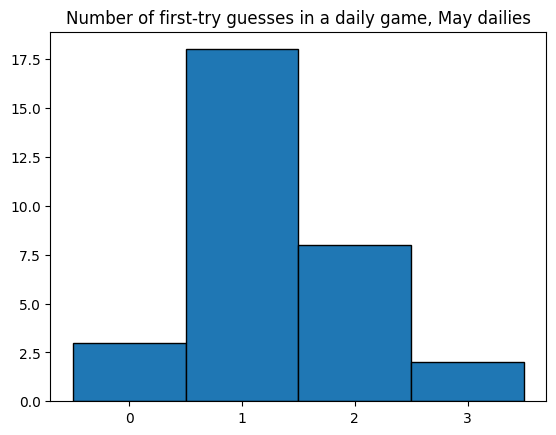

In [32]:
plt.hist(first_tries, bins=np.arange(-0.5, 4.5, 1), ec='black');
plt.xticks([0, 1, 2, 3])
plt.title('Number of first-try guesses in a daily game, May dailies');
plt.show()

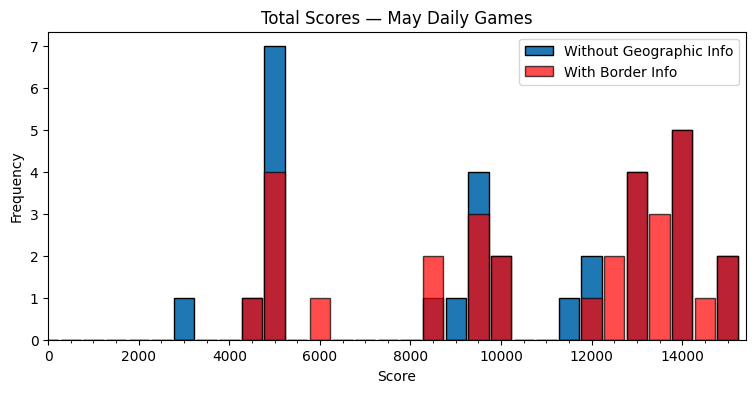

In [33]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

bins = np.arange(-250, 15750, 500)

plt.figure(figsize=(9, 4))

plt.hist(scores, bins=bins, edgecolor='black', rwidth=0.9)
plt.hist(border_scores, bins=bins, edgecolor='black', rwidth=0.9, alpha=0.7, color='red')

ax = plt.gca()

plt.xticks(np.arange(0, 16000, 2000))
ax.xaxis.set_minor_locator(MultipleLocator(500))

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim(0, 15400)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Total Scores — May Daily Games')

plt.legend(['Without Geographic Info', 'With Border Info'])

plt.show()

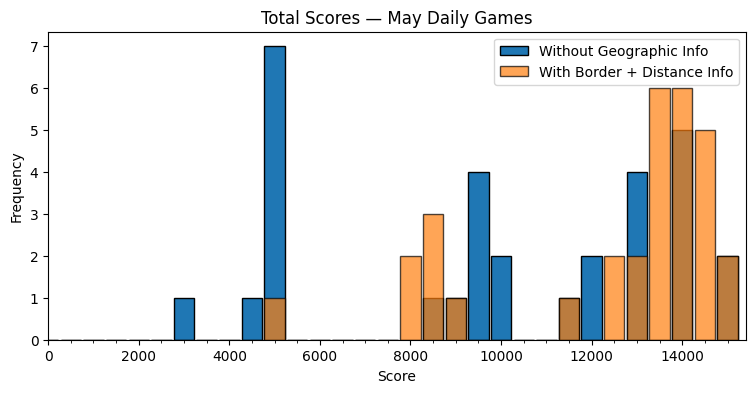

In [34]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

bins = np.arange(-250, 15750, 500)

plt.figure(figsize=(9, 4))

plt.hist(scores, bins=bins, edgecolor='black', rwidth=0.9)
plt.hist(geodist_scores, bins=bins, edgecolor='black', rwidth=0.9, alpha=0.7)

ax = plt.gca()

plt.xticks(np.arange(0, 16000, 2000))
ax.xaxis.set_minor_locator(MultipleLocator(500))

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim(0, 15400)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Total Scores — May Daily Games')

plt.legend(['Without Geographic Info', 'With Border + Distance Info'])

plt.show()

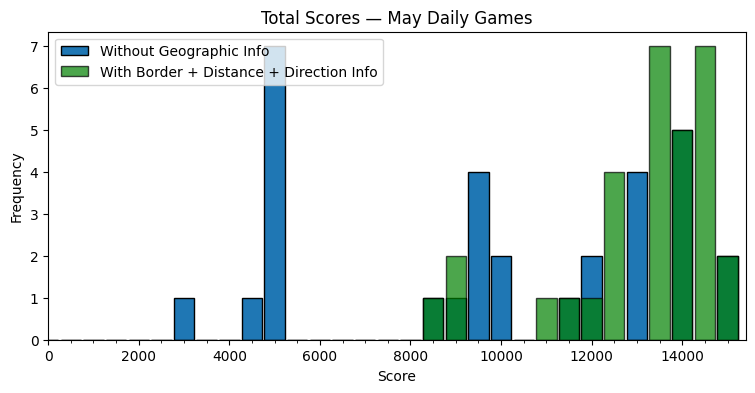

In [35]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

bins = np.arange(-250, 15750, 500)

plt.figure(figsize=(9, 4))

plt.hist(scores, bins=bins, edgecolor='black', rwidth=0.9)
plt.hist(geoall_scores, bins=bins, edgecolor='black', rwidth=0.9, alpha=0.7, color='green')

ax = plt.gca()

plt.xticks(np.arange(0, 16000, 2000))
ax.xaxis.set_minor_locator(MultipleLocator(500))

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim(0, 15400)

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Total Scores — May Daily Games')

plt.legend(['Without Geographic Info', 'With Border + Distance + Direction Info'])

plt.show()

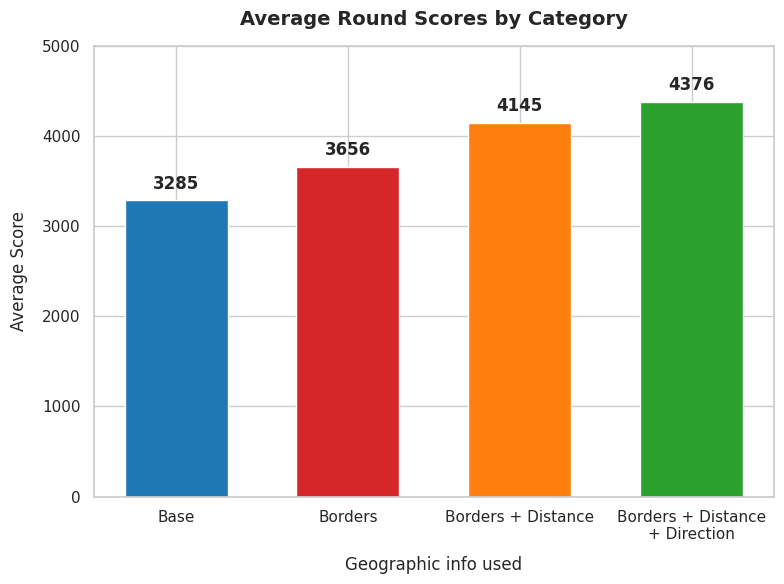

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average for each score array
categories = [
    "Base",
    "Borders",
    "Borders + Distance",
    "Borders + Distance\n+ Direction",
]
averages = [
    scores_df["scores"].mean() / 3,
    scores_df["border_scores"].mean() / 3,
    scores_df["geodist_scores"].mean() / 3,
    scores_df["geoall_scores"].mean() / 3,
]

# 2. Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

custom_colors = ["tab:blue", "tab:red", "tab:orange", "tab:green"]

# 3. Create the bar plot
# Using a pleasant palette and adjusting bar width
bars = plt.bar(categories, averages, color=custom_colors, width=0.6)

# 4. Add data labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02 * max(averages),  # Slightly above the top of the bar
        f"{yval:.0f}",  # Formats to 2 decimal places
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# 5. Customize labels and title
plt.title("Average Round Scores by Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Geographic info used", fontsize=12, labelpad=10)
plt.ylabel("Average Score", fontsize=12, labelpad=10)

# 6. Clean up presentation and show plot
plt.tight_layout()
plt.ylim(0, 5000)
plt.show()

#### individual days

In [13]:
play_daily_game_from_date("6/2/2026", rf_model=rf, mlb=mlb, show_predictions=True, use_all_geo=True)

Dish 1: Pinangat Na Isda
Countries/territories of origin: ['Philippines']
Ingredients: Fish, tomatoes, onions, kamias, salt, pepper, water, ginger, tamarind, (optional: green chilies, eggplant, mustard leaves)
Processed ingredients: ['green_chili', 'onion', 'kamia', 'salt', 'tamarind', 'eggplant', 'water', 'ginger', 'mustard', 'tomato', 'fish', 'pepper', 'chili', 'mustard_leaf']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['kamia'] will be ignored
  warnings.warn(


Prediction 1: India (17.39%)
Prediction 2: Philippines (14.02%)
Round score: 4500

Dish 2: Kefalotyri
Countries/territories of origin: ['Greece', 'Cyprus']
Ingredients: Sheep's milk, goat's milk, rennet, salt, olive oil (optional).
Processed ingredients: ['rennet', 'goat_milk', 'olive_oil', 'milk', 'goat', 'sheep_milk', 'olive', 'salt', 'oil']
Prediction 1: Spain (22.76%)
Prediction 2: Italy (15.53%)
Prediction 3: Palestine (4.89%)
Prediction 4: Lebanon (4.61%)
Prediction 5: Cyprus (0.04%)
Round score: 3000

Dish 3: Khanom Tan
Countries/territories of origin: ['Thailand']
Ingredients: Toddy palm sugar, rice flour, coconut milk, shredded coconut, baking soda, salt, pandan leaves (optional).
Processed ingredients: ['baking_soda', 'coconut', 'rice', 'salt', 'pandan_leaf', 'toddy_palm_sugar', 'milk', 'flour', 'coconut_milk', 'rice_flour', 'shredded_coconut', 'sugar']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['toddy_palm_sugar'] will be ignored
  warnings.warn(


Prediction 1: Vietnam (17.17%)
Prediction 2: Malaysia (12.88%)
Prediction 3: Thailand (10.95%)
Round score: 4000

Results:
Overall score: 11500
0 out of 3 correct first try


(11500, 0)

In [ ]:
from datetime import datetime
current_date = datetime.now().strftime("%-m/%-d/%Y")
play_daily_game_from_date(current_date, rf, mlb, show_predictions=True, use_all_geo=True)

Dish 1: Saga cheese
Countries/territories of origin: ['Denmark']
Ingredients: Cow's milk, salt, cultures, rennet, cream (optional).
Processed ingredients: ['rennet', 'milk', 'culture', 'salt', 'cream', 'cow_milk']
Prediction 1: Germany (7.09%)
Prediction 2: Switzerland (5.17%)
Prediction 3: Poland (3.15%)
Prediction 4: Denmark (1.65%)
Round score: 3500

Dish 2: Begodya
Countries/territories of origin: ['Kyrgyzstan', 'Uzbekistan', 'Kazakhstan', 'Russia']
Ingredients: wheat flour, yeast, water, salt, sugar, vegetable oil, beef, onion, cabbage, black pepper, garlic (optional), butter (optional)


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['culture'] will be ignored
  warnings.warn(


Processed ingredients: ['water', 'flour', 'vegetable_oil', 'garlic', 'butter', 'sugar', 'salt', 'wheat', 'vegetable', 'onion', 'pepper', 'beef', 'wheat_flour', 'yeast', 'cabbage', 'black_pepper', 'oil']
Prediction 1: Ukraine (7.07%)
Prediction 2: Russia (2.90%)
Round score: 4500

Dish 3: Makówki
Countries/territories of origin: ['Poland', 'Czechia', 'Germany']
Ingredients: Poppy seeds, milk, sugar, honey, bread or sweet rolls, nuts, almonds, dried fruit, butter (optional), lemon zest (optional), cinnamon (optional), vanilla extract (optional)
Processed ingredients: ['cinnamon', 'butter', 'sugar', 'honey', 'poppy_seed', 'lemon_zest', 'nut', 'dried_fruit', 'vanilla_extract', 'milk', 'lemon', 'almond', 'vanilla', 'fruit', 'bread', 'sweet_roll']
Prediction 1: Germany (14.77%)
First try!
Round score: 5000

Results:
Overall score: 13000
1 out of 3 correct first try


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['sweet_roll'] will be ignored
  warnings.warn(


(13000, 1)

### misc

In [26]:
predict_country_with_model("dubai chocolate crumbl cookie matcha latte baja blast pie", rf, mlb)

Processed ingredients: ['dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie', 'chocolate']
Prediction 1: United States (6.27%)
Prediction 2: United Kingdom (5.71%)
Prediction 3: France (4.83%)
Prediction 4: Germany (4.56%)
Prediction 5: Canada (3.89%)


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['dubai_chocolate_crumbl_cookie_matcha_latte_baja_blast_pie'] will be ignored
  warnings.warn(


['United States', 'United Kingdom', 'France', 'Germany', 'Canada']

# Model Interpretability + Stats

Goals:
- show why model made a prediction in a specific case **✓** (LIME does an okay job for "positive" contributions, ie. which ingredients in the list are most important)
- show what ingredient combinations are good predictors for each country's cuisine **✓**
- cluster countries by their ingredient lists

### LIME testing

In [34]:
foods_dict = {
    "Baghali Polo":{"Rice, dill, fava beans, saffron, oil, salt, turmeric, garlic, onion, lamb (optional), chicken (optional), butter (optional), cinnamon (optional).":["Iran"]},
    "Kaeng yot maphrao sai kai":{"Chicken, coconut shoots, coconut milk, red curry paste, fish sauce, palm sugar, kaffir lime leaves, basil, (optional) bamboo shoots, (optional) eggplant, (optional) fresh chilies, (optional) garlic, (optional) shallots":["Thailand"]},
    "Castagnaccio":{"Chestnut flour, water, olive oil, pine nuts, raisins, rosemary, walnuts (optional), orange zest (optional), fennel seeds (optional), sugar (optional), salt.":["Italy"]}
}
play_daily_game(foods_dict, rf, mlb, show_predictions=True, explainer=explainer, show_lime=True)

Dish 1: Baghali Polo
Countries/territories of origin: ['Iran']
Ingredients: Rice, dill, fava beans, saffron, oil, salt, turmeric, garlic, onion, lamb (optional), chicken (optional), butter (optional), cinnamon (optional).
Processed ingredients: ['turmeric', 'fava_bean', 'dill', 'chicken', 'saffron', 'butter', 'rice', 'salt', 'cinnamon', 'lamb', 'onion', 'bean', 'oil', 'garlic']
Prediction 1: Iran (20.73%)
Prediction 2: Azerbaijan (6.01%)
Prediction 3: Turkey (4.22%)
Prediction 4: Georgia (3.75%)
Prediction 5: Peru (3.40%)

Top contributing ingredients:
turmeric: 0.0471
saffron: 0.0409
fava_bean: 0.0100
lamb: 0.0089
dill: 0.0022
First try!
Round score: 5000

Dish 2: Kaeng yot maphrao sai kai
Countries/territories of origin: ['Thailand']
Ingredients: Chicken, coconut shoots, coconut milk, red curry paste, fish sauce, palm sugar, kaffir lime leaves, basil, (optional) bamboo shoots, (optional) eggplant, (optional) fresh chilies, (optional) garlic, (optional) shallots
Processed ingredients:

/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['coconut_shoot'] will be ignored
  warnings.warn(



Top contributing ingredients:
red_curry_paste: 0.0644
fresh_chili: 0.0398
fish_sauce: 0.0321
palm_sugar: 0.0308
coconut_milk: 0.0211
First try!
Round score: 5000

Dish 3: Castagnaccio
Countries/territories of origin: ['Italy']
Ingredients: Chestnut flour, water, olive oil, pine nuts, raisins, rosemary, walnuts (optional), orange zest (optional), fennel seeds (optional), sugar (optional), salt.
Processed ingredients: ['sugar', 'flour', 'nut', 'orange', 'fennel_seed', 'orange_zest', 'chestnut_flour', 'salt', 'fennel', 'water', 'walnut', 'olive', 'chestnut', 'raisin', 'oil', 'olive_oil', 'rosemary', 'pine_nut']
Prediction 1: Italy (22.53%)
Prediction 2: Greece (22.21%)
Prediction 3: France (14.50%)
Prediction 4: Spain (6.60%)
Prediction 5: Turkey (3.64%)

Top contributing ingredients:
olive_oil: 0.0619
chestnut_flour: 0.0355
olive: 0.0309
rosemary: 0.0218
fennel: 0.0047
First try!
Round score: 5000

Results:
Overall score: 15000
3 out of 3 correct first try


### Find useful ingredients to distinguish each country

#### Let's try log-odds!

In [119]:
# get every pair of ingredients, excluding the base ingredients vs processed ingredient pairs
from itertools import combinations

ingredients = unique_dishes_df["ingredients"].explode().unique()

pairs = set()

for ing1, ing2 in combinations(sorted(ingredients), 2):

    tokens1 = set(ing1.split("_"))
    tokens2 = set(ing2.split("_"))

    if tokens1.issubset(tokens2) or tokens2.issubset(tokens1):
        continue

    pairs.add((ing1, ing2))

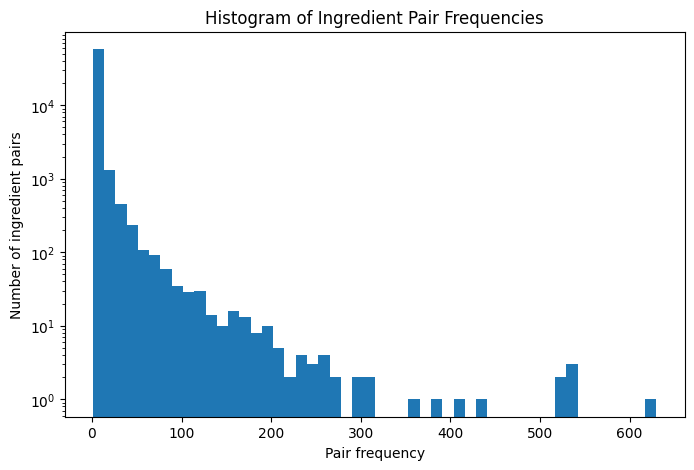

In [120]:
# filter for more common pairs
from collections import Counter

pair_counts = Counter()

# count ingredient pairs per dish
for ingredients in unique_dishes_df["ingredients"]:

    ingredients = sorted(set(ingredients))  # remove duplicates within dish

    for pair in combinations(ingredients, 2):
        pair_counts[pair] += 1

# convert to dataframe
pair_freq_df = pd.DataFrame(
    [
        {
            "ingredient_1": pair[0],
            "ingredient_2": pair[1],
            "frequency": count
        }
        for pair, count in pair_counts.items()
    ]
)

# optional: sort descending
pair_freq_df = pair_freq_df.sort_values(
    "frequency",
    ascending=False
)

# histogram
plt.figure(figsize=(8, 5))
plt.hist(pair_freq_df["frequency"], bins=50)

plt.xlabel("Pair frequency")
plt.ylabel("Number of ingredient pairs")
plt.title("Histogram of Ingredient Pair Frequencies")
plt.yscale("log")

plt.show()

In [121]:
# find pairs that appear at least 10 times
filtered_pair_df = pair_freq_df[pair_freq_df["frequency"] >= 10]

# remove pairs containing salt or pepper
filtered_pair_df = filtered_pair_df[
    ~(
        filtered_pair_df["ingredient_1"].str.contains("salt|pepper")
        |
        filtered_pair_df["ingredient_2"].str.contains("salt|pepper")
    )
]

filtered_ingredient_pairs = list(
    zip(
        filtered_pair_df["ingredient_1"],
        filtered_pair_df["ingredient_2"]
    )
)

# find ingredients that appear at least twice...filters out some weird descriptions and ingredients that may not be informative beyond a specific dish
counts = unique_dishes_df["ingredients"].explode().value_counts()
filtered_ingredients = counts[counts >= 2].index

len(filtered_ingredient_pairs), len(filtered_ingredients)

(2956, 957)

In [122]:
country = "Peru"

alpha = 1  # smoothing constant

# count dishes
country_mask = unique_dishes_df["countries_of_origin"].apply(
    lambda countries: country in countries
)

country_df = unique_dishes_df[country_mask]
rest_df = unique_dishes_df[~country_mask]

N_country = len(country_df)
N_rest = len(rest_df)

# initialize counters
country_counts = Counter()
rest_counts = Counter()

# helper function
def extract_features(ingredients):

    ingredients = set(ingredients)

    features = set()

    # single ingredients
    for ing in ingredients:
        if ing in filtered_ingredients:
            features.add(ing)

    # ingredient pairs
    ingredient_pairs_in_dish = {
        tuple(sorted(pair))
        for pair in combinations(sorted(ingredients), 2)
    }

    for pair in ingredient_pairs_in_dish:
        if pair in filtered_ingredient_pairs:
            features.add(pair)

    return features

# count country features
for ingredients in country_df["ingredients"]:

    features = extract_features(ingredients)

    for feature in features:
        country_counts[feature] += 1

# count rest-of-world features
for ingredients in rest_df["ingredients"]:

    features = extract_features(ingredients)

    for feature in features:
        rest_counts[feature] += 1

# all observed features
all_features = (
    set(country_counts.keys())
    | set(rest_counts.keys())
)

# compute log odds
results = []

for feature in all_features:

    c_i = country_counts[feature]
    r_i = rest_counts[feature]

    odds_country = (
        (c_i + alpha)
        /
        (N_country - c_i + alpha)
    )

    odds_rest = (
        (r_i + alpha)
        /
        (N_rest - r_i + alpha)
    )

    log_odds = np.log(odds_country / odds_rest)

    # frequency-weighted score
    weighted_score = log_odds * (1 + 0.5 * np.log1p(c_i))

    results.append({
        "feature": feature,
        "country_count": c_i,
        "rest_count": r_i,
        "log_odds": log_odds,
        "weighted_score": weighted_score
    })

# dataframe of results
log_odds_df = pd.DataFrame(results)

# sort by weighted score instead
log_odds_df = log_odds_df.sort_values(
    "weighted_score",
    ascending=False
)

num_dishes = unique_dishes_df["countries_of_origin"].apply(
    lambda countries: country in countries
).sum()

print(f"Number of unique dishes from {country}: {num_dishes}")
print(log_odds_df.head(20))

def foods_for_country(country):
    return unique_dishes_df[
        unique_dishes_df["countries_of_origin"].apply(
            lambda countries: country in countries
        )
    ]

foods_for_country(country).head(10)

Number of unique dishes from Peru: 35
                        feature  country_count  rest_count  log_odds  \
3425               aji_amarillo              7           0  6.155224   
1370                  aji_panca              3           0  5.332865   
1854         aji_amarillo_paste              2           0  5.015330   
2574             chinese_noodle              2           0  5.015330   
703                    raw_fish              2           1  4.321597   
2523          (oregano, potato)              4           6  3.637351   
94              (corn, parsley)              4           6  3.637351   
3436                (corn, pea)              5          11  3.309483   
2342             (corn, potato)              8          27  2.959960   
3633         (cumin, vegetable)              4           8  3.384861   
3242              (cumin, lime)              5          13  3.154153   
3393            (cilantro, pea)              4           9  3.278912   
2698              (pea, po

,dish_name,countries_of_origin,ingredients
50,Picarón,"[Peru, Chile]","[pumpkin, clove, sugar, potato, cinnamon, egg,..."
140,Olluquito,[Peru],"[onion, olluco, red_onion, beef, potato, cilan..."
159,Inca Kola,[Peru],"[sugar, carbonated_water, yellow_dye, citru_ex..."
218,Alpaca en salsa de aguaymanto,[Peru],"[onion, alpaca_meat, wine, chili, sugar, black..."
372,Lomo Saltado,[Peru],"[onion, rice, cumin, beef, garlic, french_fry,..."
378,Sancochado,[Peru],"[cabbage, onion, black_pepper, potato, chickpe..."
436,Aeropuerto,[Peru],"[onion, shrimp, oil, rice, vegetable, noodle, ..."
455,Cuy,"[Peru, Colombia, Bolivia, Ecuador]","[wheat, onion, achiote, cumin, flour, wheat_fl..."
458,Ceviche,[Peru],"[onion, corn, chili, fish, lettuce, red_onion,..."
478,Salchipapa,"[Brazil, French Guiana, Uruguay, Guyana, Peru,...","[ketchup, hot_dog, lettuce, mayonnaise, mustar..."


#### export top 5 pairs, top 5 single ingredients for every country and territory with at least 10 dishes

In [125]:
from collections import Counter
from itertools import combinations
import numpy as np
import pandas as pd


alpha = 1
min_dishes = 10


# ---------- helper function ----------
def extract_features(ingredients):

    ingredients = set(ingredients)

    features = set()

    # single ingredients
    for ing in ingredients:
        if ing in filtered_ingredients:
            features.add(ing)

    # ingredient pairs
    ingredient_pairs_in_dish = {
        tuple(sorted(pair))
        for pair in combinations(sorted(ingredients), 2)
    }

    for pair in ingredient_pairs_in_dish:
        if pair in filtered_ingredient_pairs:
            features.add(pair)

    return features


# ---------- main function ----------
def export_country_feature_scores(country_list, output_csv="country_feature_scores.csv"):

    all_country_results = []

    for country in country_list:

        print(f"Processing {country}...")

        # country vs rest split
        country_mask = unique_dishes_df["countries_of_origin"].apply(
            lambda countries: country in countries
        )

        country_df = unique_dishes_df[country_mask]
        rest_df = unique_dishes_df[~country_mask]

        N_country = len(country_df)
        N_rest = len(rest_df)

        # skip countries with too few dishes
        if N_country < min_dishes:
            print(f"Skipping {country} (< {min_dishes} dishes)")
            continue

        country_counts = Counter()
        rest_counts = Counter()

        # count features in country dishes
        for ingredients in country_df["ingredients"]:

            features = extract_features(ingredients)

            for feature in features:
                country_counts[feature] += 1

        # count features in rest-of-world dishes
        for ingredients in rest_df["ingredients"]:

            features = extract_features(ingredients)

            for feature in features:
                rest_counts[feature] += 1

        all_features = (
            set(country_counts.keys())
            | set(rest_counts.keys())
        )

        results = []

        for feature in all_features:

            c_i = country_counts[feature]
            r_i = rest_counts[feature]

            odds_country = (
                (c_i + alpha)
                /
                (N_country - c_i + alpha)
            )

            odds_rest = (
                (r_i + alpha)
                /
                (N_rest - r_i + alpha)
            )

            log_odds = np.log(odds_country / odds_rest)

            # frequency-weighted score
            weighted_score = log_odds * (1 + 0.5 * np.log1p(c_i))

            results.append({
                "feature": feature,
                "country_count": c_i,
                "rest_count": r_i,
                "log_odds": log_odds,
                "weighted_score": weighted_score,
                "feature_type": "pair" if isinstance(feature, tuple) else "ingredient"
            })

        results_df = pd.DataFrame(results)

        # ---------- top single ingredients ----------
        top_ingredients = (
            results_df[
                results_df["feature_type"] == "ingredient"
            ]
            .sort_values("weighted_score", ascending=False)
            .head(5)
            .copy()
        )

        top_ingredients["country"] = country

        # ---------- top ingredient pairs ----------
        top_pairs = (
            results_df[
                results_df["feature_type"] == "pair"
            ]
            .sort_values("weighted_score", ascending=False)
            .head(5)
            .copy()
        )

        top_pairs["country"] = country

        # convert tuples to strings for CSV readability
        top_pairs["feature"] = top_pairs["feature"].apply(
            lambda x: " + ".join(x)
        )

        all_country_results.append(top_ingredients)
        all_country_results.append(top_pairs)

    # combine all countries
    final_df = pd.concat(all_country_results, ignore_index=True)

    # export
    final_df.to_csv(output_csv, index=False)

    print(f"Saved results to: {output_csv}")

    return final_df

In [126]:
country_list = [
        "Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Argentina", "Armenia", 
        "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", 
        "Belarus", "Belgium", "Belize", "Benin", "Bhutan", "Bolivia", "Bosnia and Herzegovina", 
        "Botswana", "Brazil", "Brunei", "Bulgaria", "Burkina Faso", "Burundi", "Cambodia", 
        "Cameroon", "Canada", "Cape Verde", "Central African Republic", "Chad", "Chile", "China", 
        "Colombia", "Comoros", "Congo", "Costa Rica", "Croatia", "Cuba", "Cyprus", "Czech Republic", 
        "Czechia", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", 
        "El Salvador", "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia", "Fiji", 
        "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada", 
        "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hungary", "Iceland", 
        "India", "Indonesia", "Iran", "Iraq", "Ireland", "Israel", "Italy", "Jamaica", "Japan", 
        "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Kyrgyzstan", "Laos", "Latvia", 
        "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein", "Lithuania", "Luxembourg", 
        "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", 
        "Mauritania", "Mauritius", "Mexico", "Micronesia", "Moldova", "Monaco", "Mongolia", 
        "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", 
        "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Korea", "North Macedonia", "Norway", 
        "Oman", "Pakistan", "Palau", "Palestine", "Panama", "Papua New Guinea", "Paraguay", "Peru", 
        "Philippines", "Poland", "Portugal", "Qatar", "Romania", "Russia", "Rwanda", "Saint Kitts and Nevis", 
        "Saint Lucia", "Saint Vincent and the Grenadines", "Samoa", "San Marino", "Sao Tome and Principe", 
        "Saudi Arabia", "Senegal", "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", 
        "Slovenia", "Solomon Islands", "Somalia", "South Africa", "South Korea", "South Sudan", "Spain", 
        "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria", "Taiwan", "Tajikistan", 
        "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga", "Trinidad and Tobago", "Tunisia", 
        "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates", "United Kingdom", 
        "United States", "Uruguay", "Uzbekistan", "Vanuatu", "Vatican City", "Venezuela", "Vietnam", 
        "Yemen", "Zambia", "Zimbabwe",
        "Hong Kong", "Macau", "Palestine", "Puerto Rico", "Greenland", "Faroe Islands", "French Guiana", "Gibraltar",
        "Isle of Man", "Jersey", "Guernsey", "Aruba", "Curacao", "Sint Maarten", "Bonaire", "Saba", "Saint Barthélemy",
        "Saint Martin", "Saint Pierre and Miquelon", "Wallis and Futuna", "Western Sahara", "Kosovo", "Antigua and Barbuda", "Curaçao",
        "Saint Helena, Ascension and Tristan da Cunha", "Cook Islands", "Niue", "Tokelau", "Åland Islands", "Ivory Coast", "Côte d'Ivoire",
        "French Southern and Antarctic Lands", "Réunion", "Mayotte", "Guadaloupe", "Martinique", "Saint Pierre and Miquelon",
        "Bermuda", "British Virgin Islands", "Falkland Islands", "Montserrat", "Turks and Caicos Islands", "Virgin Islands",
        "Guadeloupe", "Cayman Islands", "Republic of the Congo", "São Tomé and Príncipe", "DR Congo", "American Samoa",  "French Polynesia",
        "Cocos (Keeling) Islands", "Christmas Island", "Guam"
]

results_df = export_country_feature_scores(country_list)

Processing Afghanistan...
Processing Albania...
Skipping Albania (< 10 dishes)
Processing Algeria...
Processing Andorra...
Skipping Andorra (< 10 dishes)
Processing Angola...
Skipping Angola (< 10 dishes)
Processing Argentina...
Processing Armenia...
Processing Australia...
Processing Austria...
Processing Azerbaijan...
Processing Bahamas...
Skipping Bahamas (< 10 dishes)
Processing Bahrain...
Processing Bangladesh...
Processing Barbados...
Skipping Barbados (< 10 dishes)
Processing Belarus...
Processing Belgium...
Processing Belize...
Skipping Belize (< 10 dishes)
Processing Benin...
Skipping Benin (< 10 dishes)
Processing Bhutan...
Skipping Bhutan (< 10 dishes)
Processing Bolivia...
Processing Bosnia and Herzegovina...
Processing Botswana...
Skipping Botswana (< 10 dishes)
Processing Brazil...
Processing Brunei...
Processing Bulgaria...
Processing Burkina Faso...
Skipping Burkina Faso (< 10 dishes)
Processing Burundi...
Skipping Burundi (< 10 dishes)
Processing Cambodia...
Processing

#### Remnant of debugging... real ones will remember rice is made of ice...

In [123]:
ice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings
).sum()

rice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "rice" in ings
).sum()

ice_rice_count = unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings and "rice" in ings
).sum()

print("Dishes with ice:", ice_count)
print("Dishes with rice:", rice_count)
print("Dishes with both:", ice_rice_count)

Dishes with ice: 37
Dishes with rice: 297
Dishes with both: 4


In [124]:
unique_dishes_df[unique_dishes_df["ingredients"].apply(
    lambda ings: "ice" in ings and "rice" in ings
)]

,dish_name,countries_of_origin,ingredients
30,Shwe Yin Aye,[Myanmar],"[coconut_milk, rice, ice, sugar, pandan_leaf, ..."
887,Khao Chae,[Thailand],"[coconut_milk, turmeric, ice, shrimp, kaffir_l..."
1378,Namkhaeng Sai,[Thailand],"[coconut_cream, jackfruit, ice, milk, fruit, g..."
1587,Cendol,"[Brunei, Malaysia, Cambodia, Vietnam, Indonesi...","[coconut_milk, red_bean, corn, rice, rice_flou..."


In [45]:
display_ingredients("Khao Chae")

'jasmine rice, water, flower-scented water, ice sides include shrimp paste, shallots, garlic, dried fish, pork, sugar, salt, turmeric, white pepper, coconut milk, chilies, lemongrass, ginger, coriander, kaffir lime leaves, roasted rice powder, peanuts, mung beans, pickled vegetables'

# Misc stuff...

#### trying to reverse engineer how foodguessr treats temperature/distance ratings when multiple countries are correct...

In [17]:
from geography import get_country_distance, temperature_label_from_distance
import numpy as np


guess = "Equatorial Guinea"
correct = ["Gambia", "Nigeria", "Cape Verde", "Sierra Leone", "Benin", "Ghana", "Niger", "Guinea", "Guinea-Bissau", "Mali", "Senegal", "Burkina Faso", "Togo", "Mauritania", "Liberia"]
distances = [get_country_distance(guess, c) for c in correct]
print(distances)
print(f"Average distance: {np.average(distances)}: {temperature_label_from_distance(np.average(distances))}")
print(f"Min distance: {min(distances)}: {temperature_label_from_distance(min(distances))}")

[3029, 870, 4259, 2591, 1242, 1459, 1768, 2411, 2963, 2152, 3108, 1742, 1303, 3206, 2301]
Average distance: 2293.6: Warm
Min distance: 870: Hot


#### trying to reverse engineer how direction is shown...

In [18]:
from geography import get_guess_direction

directions = [round(get_guess_direction(guess, [c])) for c in correct]
print(directions)

print(f"Average direction: {np.average(directions)}")
print(f"Direction of closest country: {directions[np.argmin(distances)]}")

[297, 341, 296, 288, 314, 299, 358, 293, 294, 326, 299, 313, 307, 314, 284]
Average direction: 308.2
Direction of closest country: 341


#### bleh

In [ ]:
import pandas as pd
unique_dishes_df = pd.read_csv("data/data.csv").drop_duplicates(subset=["dish_name", "countries_of_origin"])
len(unique_dishes_df)

2246

In [2]:
import pandas as pd
unique_dishes_df = pd.read_csv("data/unique_processed_data_05_2026.csv").drop_duplicates(subset=["dish_name", "countries_of_origin"])
peru_df = unique_dishes_df[lambda df: df["countries_of_origin"].apply(lambda countries: "Peru" in countries)]
len(peru_df)

35

In [4]:
len(peru_df[lambda df: df["ingredients"].apply(lambda ings: "aji" in ings.lower() or "ají" in ings.lower() or "rocoto" in ings.lower())])

13

In [58]:
peru_df[lambda df: df["ingredients"].apply(lambda ings: "chinese_noodle" in ings)]

,dish_name,countries_of_origin,ingredients
436,Aeropuerto,['Peru'],"['egg', 'oil', 'noodle', 'garlic', 'pork', 're..."
958,Tallarín Saltado,['Peru'],"['bell_pepper', 'aji_amarillo_paste', 'green_o..."
